#EDA – CICIDS2017 Intrusion Detection Dataset

## 📋 Table of Contents
1. Import Libraries
2. Load the Dataset
3. Dataset Shape and Data Types
4. Missing Values Analysis
5. Infinite Values Inf Analysis
6. Duplicate Records
7. Target Variable Distribution
8. Numerical Features Analysis
9. Outliers
10. Correlation Analysis
11. Negative Values and Their Treatment
12. Feature Engineering
13. Insights and Findings

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

### 2. Load the Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("elshewey/intrusion-detection-cicids2017")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'intrusion-detection-cicids2017' dataset.
Path to dataset files: /kaggle/input/intrusion-detection-cicids2017
['cicids2017_binary_balanced.csv']


In [3]:
df = pd.read_csv(f'{path}/cicids2017_binary_balanced.csv')
print(f"Data has been downloaded successfully, shape: {df.shape}")
# Show first 5 rows (default)
df.head()

Data has been downloaded successfully, shape: (851388, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack_Binary
0,80,5121659,3,12,6,0,4.0,3.464102,0,0,...,17922,2,20,0.0,0,0,0.0,0,0,0
1,53,128476,1,53,53,53,53.0,0.000000,116,116,...,-1,0,32,0.0,0,0,0.0,0,0,0
2,53,23701,1,53,53,53,53.0,0.000000,69,69,...,-1,0,32,0.0,0,0,0.0,0,0,0
3,54549,4,2,0,0,0,0.0,0.000000,0,0,...,-1,0,20,0.0,0,0,0.0,0,0,0
4,53,252129,1,58,58,58,58.0,0.000000,202,202,...,-1,0,32,0.0,0,0,0.0,0,0,0


### 3. Dataset Shape and Data Types

In [4]:
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}\n")
df.info()

Number of rows: 851388
Number of columns: 53

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851388 entries, 0 to 851387
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             851388 non-null  int64  
 1   Flow Duration                851388 non-null  int64  
 2   Total Fwd Packets            851388 non-null  int64  
 3   Total Length of Fwd Packets  851388 non-null  int64  
 4   Fwd Packet Length Max        851388 non-null  int64  
 5   Fwd Packet Length Min        851388 non-null  int64  
 6   Fwd Packet Length Mean       851388 non-null  float64
 7   Fwd Packet Length Std        851388 non-null  float64
 8   Bwd Packet Length Max        851388 non-null  int64  
 9   Bwd Packet Length Min        851388 non-null  int64  
 10  Bwd Packet Length Mean       851388 non-null  float64
 11  Bwd Packet Length Std        851388 non-null  float64
 12  Flow Bytes/s

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,851388.0,6.018726e+03,1.580876e+04,0.000000e+00,80.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,851388.0,2.529692e+07,4.069142e+07,-1.200000e+01,233.000000,152464.000000,6.111025e+07,1.200000e+08
Total Fwd Packets,851388.0,7.891141e+00,6.086470e+02,1.000000e+00,2.000000,3.000000,7.000000e+00,2.177970e+05
Total Length of Fwd Packets,851388.0,4.510264e+02,4.643518e+03,0.000000e+00,12.000000,58.000000,3.470000e+02,1.288022e+06
Fwd Packet Length Max,851388.0,1.988623e+02,6.101834e+02,0.000000e+00,6.000000,36.000000,3.220000e+02,2.482000e+04
Fwd Packet Length Min,851388.0,1.224016e+01,5.074153e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,2.065000e+03
Fwd Packet Length Mean,851388.0,5.082777e+01,1.585303e+02,0.000000e+00,6.000000,32.000000,5.200000e+01,5.940857e+03
Fwd Packet Length Std,851388.0,7.056834e+01,2.379194e+02,0.000000e+00,0.000000,0.000000,1.170262e+02,7.125597e+03
Bwd Packet Length Max,851388.0,2.049651e+03,3.028887e+03,0.000000e+00,6.000000,113.000000,4.344000e+03,1.168000e+04
Bwd Packet Length Min,851388.0,2.654858e+01,5.953124e+01,0.000000e+00,0.000000,0.000000,6.000000e+00,1.983000e+03


# 4. Missing Values

In [6]:
# Count missing per column
missing = df.isnull().sum()

if missing[missing > 0].empty:
  print('No missing values in the data')

else:
  print("There're some missing valuse\nMissing values percentage:")

  # Percentage of missing values
  missing_pct = (df.isnull().sum() / len(df)) * 100
  print(missing_pct[missing_pct > 0].sort_values(ascending=False))

  # Missing values count
  print('Missing values per column:\n',missing[missing > 0])

No missing values in the data


# 4. Infinite Values

In [7]:
inf_counts = np.isinf(df.select_dtypes(include=np.number)).sum()
inf_found  = inf_counts[inf_counts > 0]

if inf_found.empty:
    print("No infinite values in the data")
else:
    print("There're some infinite valuse\nInfinite values:")
    print(inf_found)

    # Replacing the Inf values with nan then the median
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)

    print("Inf values has been replaced with the median")

No infinite values in the data


# 6. Duplicate Records

In [8]:
# Count duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Show the actual duplicate rows
df[df.duplicated()]

Duplicate rows: 8


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack_Binary
49843,443,49,2,0,0,0,0.0,0.0,0,0,...,-1,0,32,0.0,0,0,0.0,0,0,0
118751,58726,63,1,0,0,0,0.0,0.0,0,0,...,32832,0,32,0.0,0,0,0.0,0,0,0
255979,443,3,1,6,6,6,6.0,0.0,6,6,...,32,0,20,0.0,0,0,0.0,0,0,0
259532,51244,35,1,0,0,0,0.0,0.0,0,0,...,33304,0,32,0.0,0,0,0.0,0,0,0
288180,443,2,1,0,0,0,0.0,0.0,0,0,...,122,0,32,0.0,0,0,0.0,0,0,0
381089,443,2,1,0,0,0,0.0,0.0,0,0,...,349,0,32,0.0,0,0,0.0,0,0,0
393438,52841,40,1,0,0,0,0.0,0.0,0,0,...,33304,0,32,0.0,0,0,0.0,0,0,0
404213,443,5,2,0,0,0,0.0,0.0,0,0,...,-1,0,32,0.0,0,0,0.0,0,0,0


In [9]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f"Duplicated rows has been dropped, the new shape: {df.shape}")
else:
    print("no duplicated recoreds")

Duplicated rows has been dropped, the new shape: (851380, 53)


# 7. Target Distribution

In [10]:
warnings.filterwarnings('ignore')

                Count  Percentage
Attack_Binary                    
1              425694        50.0
0              425686        50.0


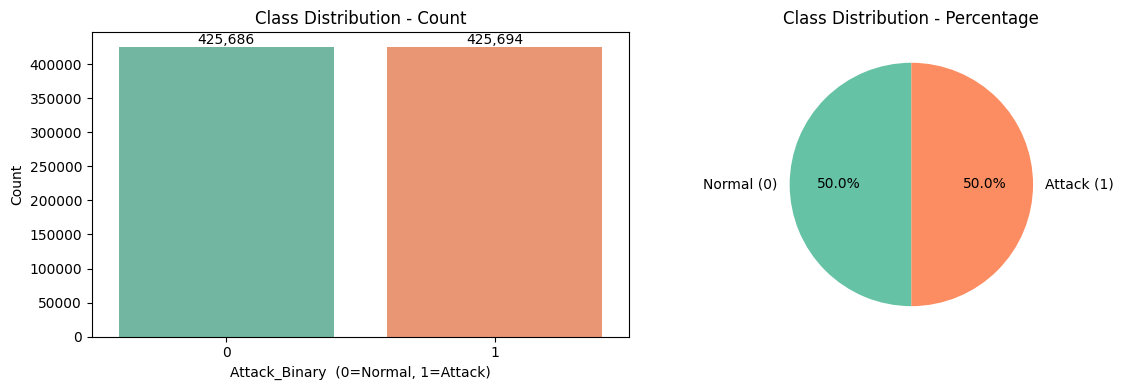

In [11]:
TARGET = 'Attack_Binary'

# Count and Percentage of Target
dist = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': dist, 'Percentage': dist_pct.round(2)})
print(summary)

# Countplot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=TARGET, data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Class Distribution - Count')
axes[0].set_xlabel('Attack_Binary  (0=Normal, 1=Attack)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(dist, labels=['Normal (0)', 'Attack (1)'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2'))
axes[1].set_title('Class Distribution - Percentage')

plt.tight_layout()
plt.show()

# 8. Numerical Feature Analysis

In [12]:
# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns.tolist()

# Feature Columns
feature_cols = [c for c in num_cols if c != TARGET]

print(f"Numerical: {len(num_cols)}")
print(f"Categorical: {len(cat_cols)}")
print(f"Feature Columns: {len(feature_cols)}")

Numerical: 53
Categorical: 0
Feature Columns: 52


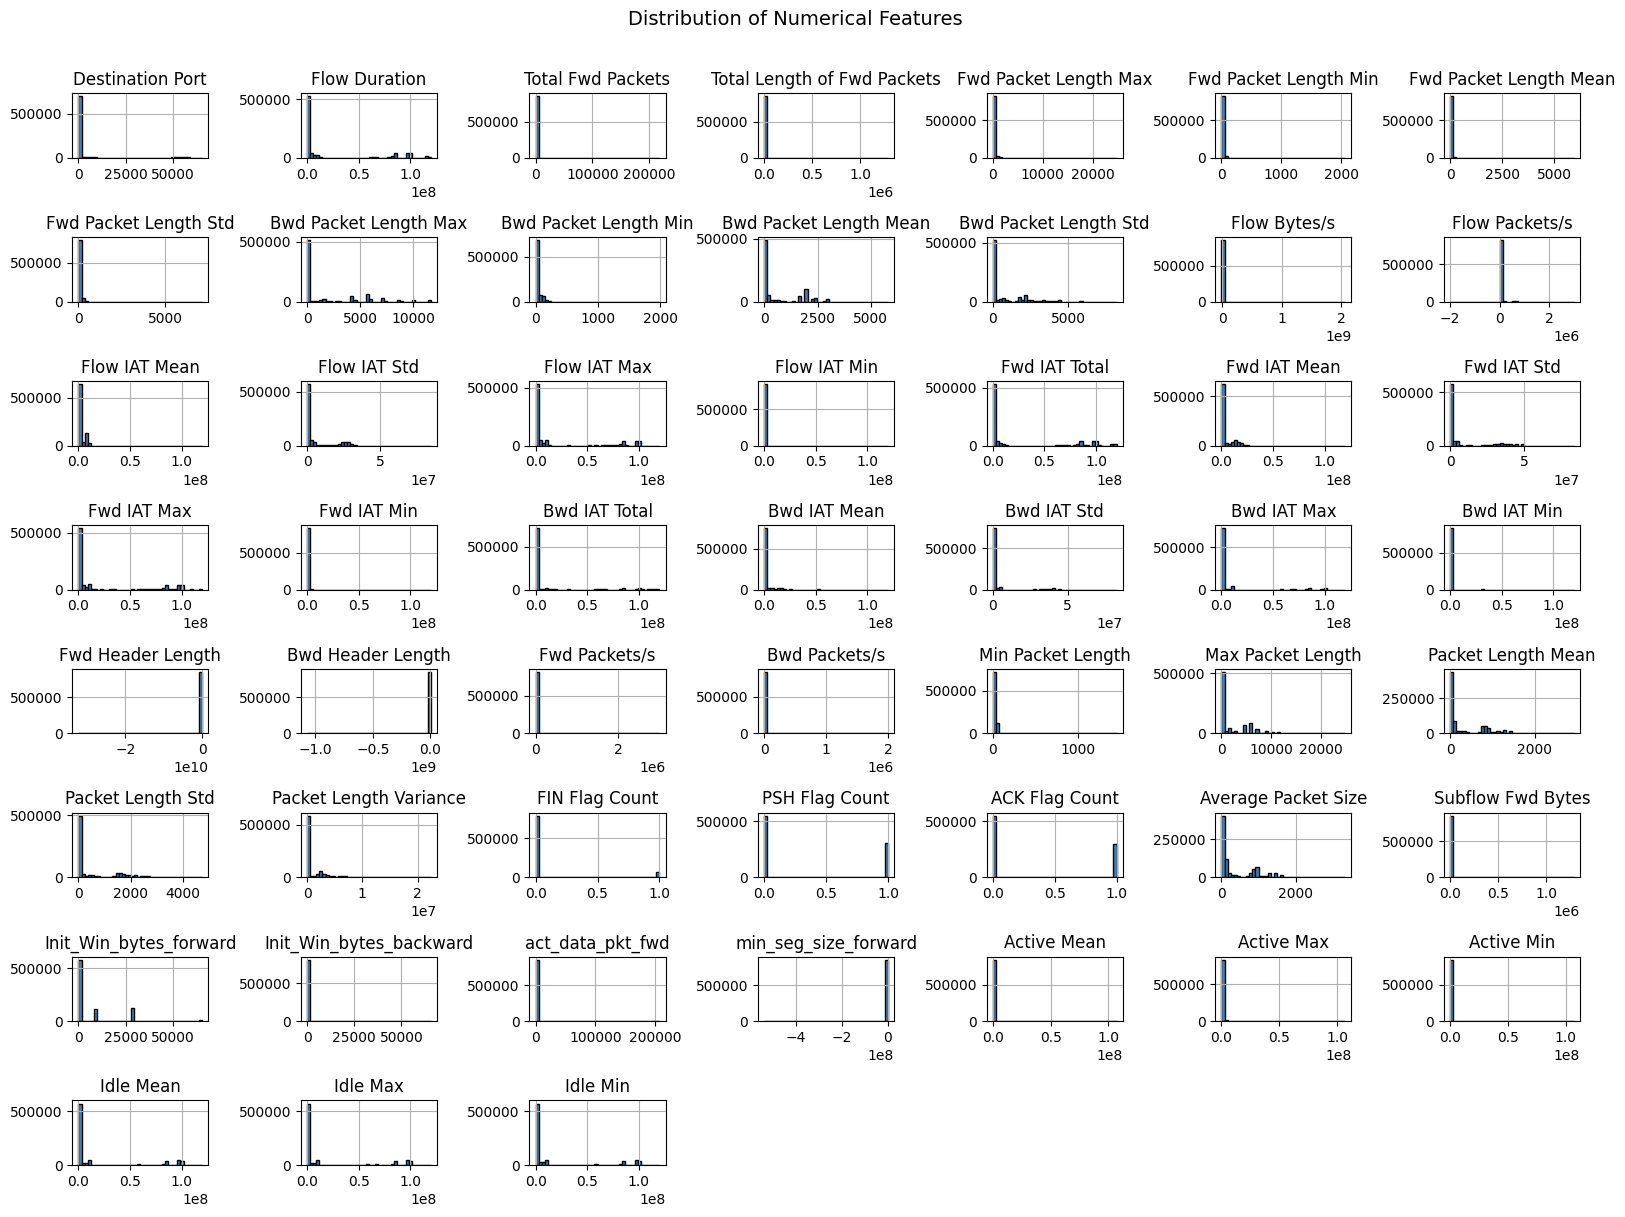

In [13]:
# Distribution of all Numerical Columns
df[feature_cols].hist(figsize=(16, 12), bins=40,
                       color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Outliers

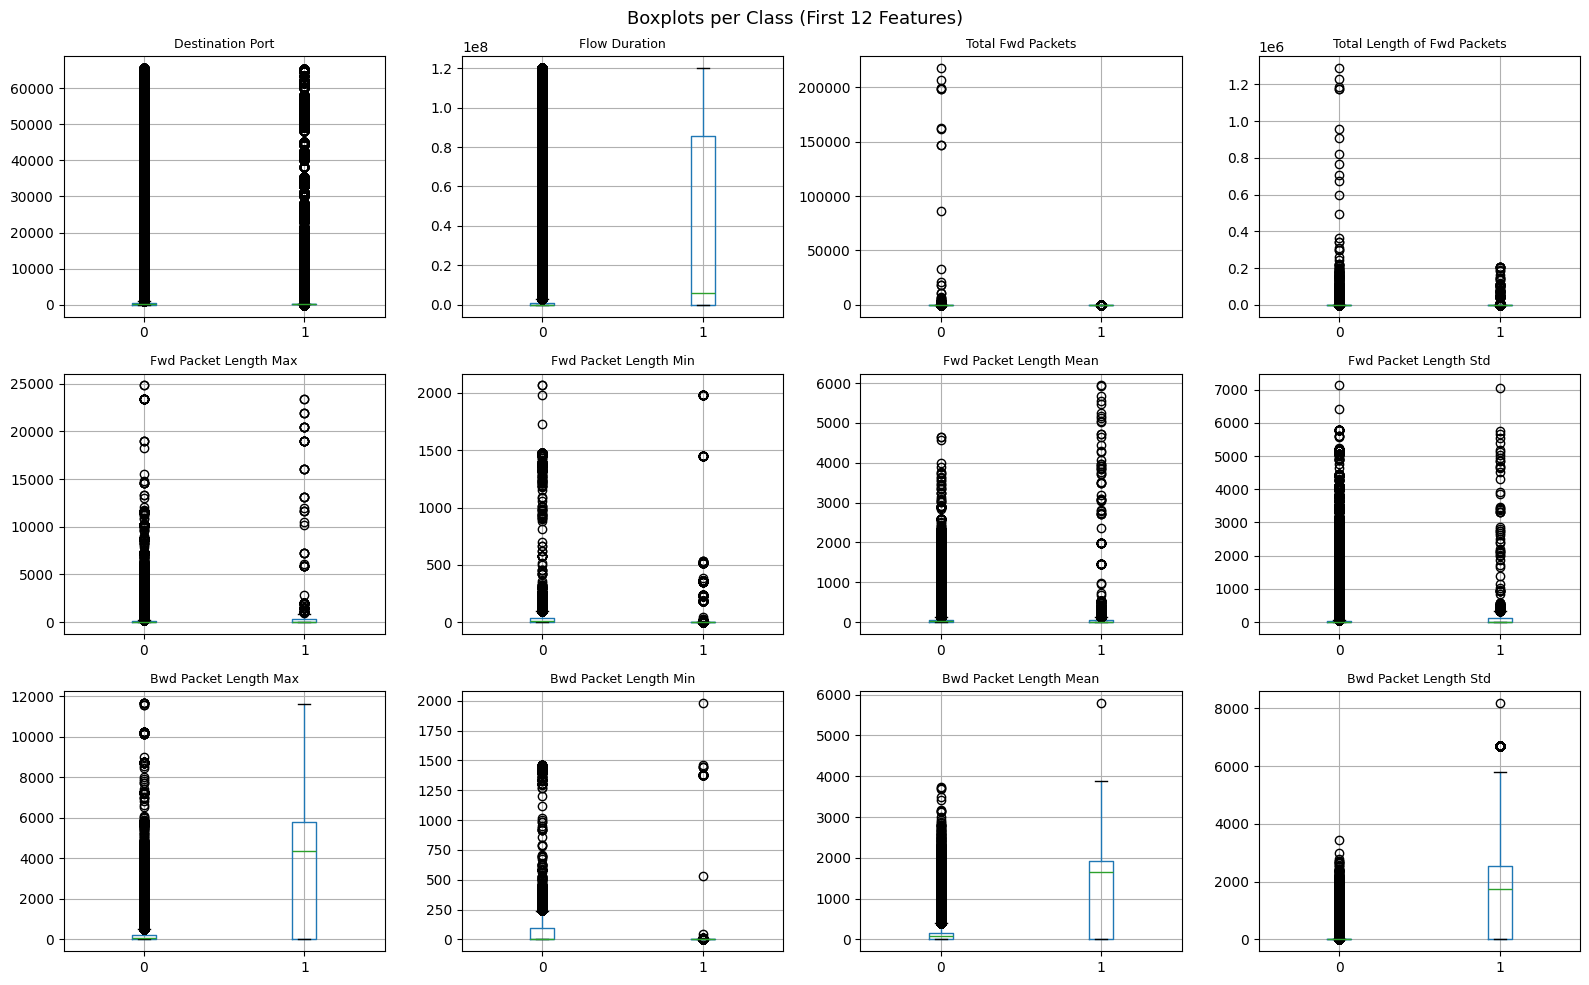

In [14]:
# Boxplots for Outlier Detection - First 12 Features
sample_cols = feature_cols[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(sample_cols):
    df.boxplot(column=col, by=TARGET, ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Boxplots per Class (First 12 Features)', fontsize=13)
plt.tight_layout()
plt.show()

# 10. Correlation Analysis

Top 10 Positively (+) Correlated Features:
Bwd Packet Length Mean    0.544237
Bwd Packet Length Std     0.536606
Bwd Packet Length Max     0.535645
Packet Length Std         0.525011
Max Packet Length         0.516244
Packet Length Mean        0.501189
Average Packet Size       0.496381
Packet Length Variance    0.463450
Fwd IAT Std               0.453875
Idle Max                  0.442664

Top 10 Negatively (-) Correlated Features:
Bwd IAT Min               -0.048874
Fwd Packet Length Max     -0.082057
Flow Packets/s            -0.111606
Fwd Packet Length Mean    -0.123698
Fwd Packets/s             -0.126561
Init_Win_bytes_backward   -0.154221
Fwd Packet Length Min     -0.211302
Destination Port          -0.256782
Bwd Packet Length Min     -0.421257
Min Packet Length         -0.425010


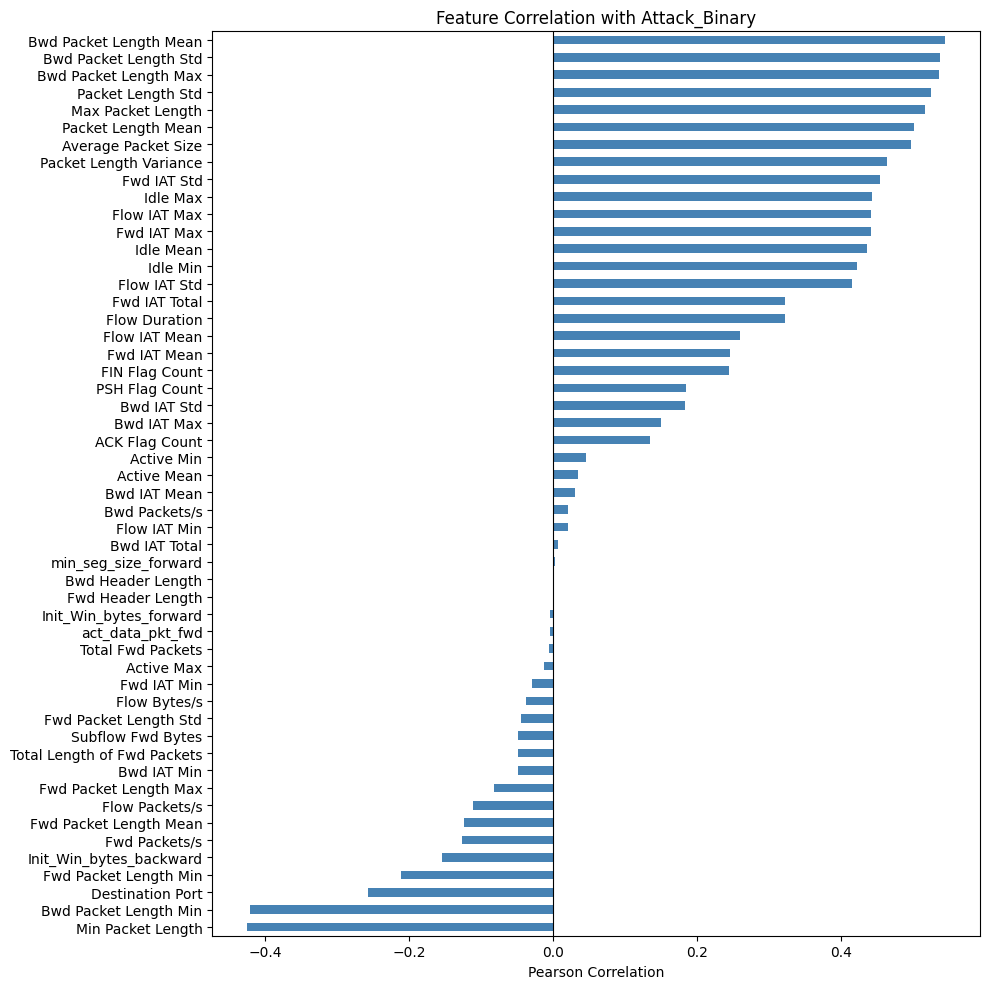

In [17]:
# Correlation of Each Feature with the Target Variable
corr = df[num_cols].corr()
corr_target = corr[TARGET].drop(TARGET).sort_values(ascending=False)

print("Top 10 Positively (+) Correlated Features:")
print(corr_target.head(10).to_string())

print("\nTop 10 Negatively (-) Correlated Features:")
print(corr_target.tail(10).to_string())

# plot
plt.figure(figsize=(10, 8))
corr_target.sort_values().plot(kind='barh', color='steelblue', figsize=(10, 10))
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Feature Correlation with {TARGET}')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

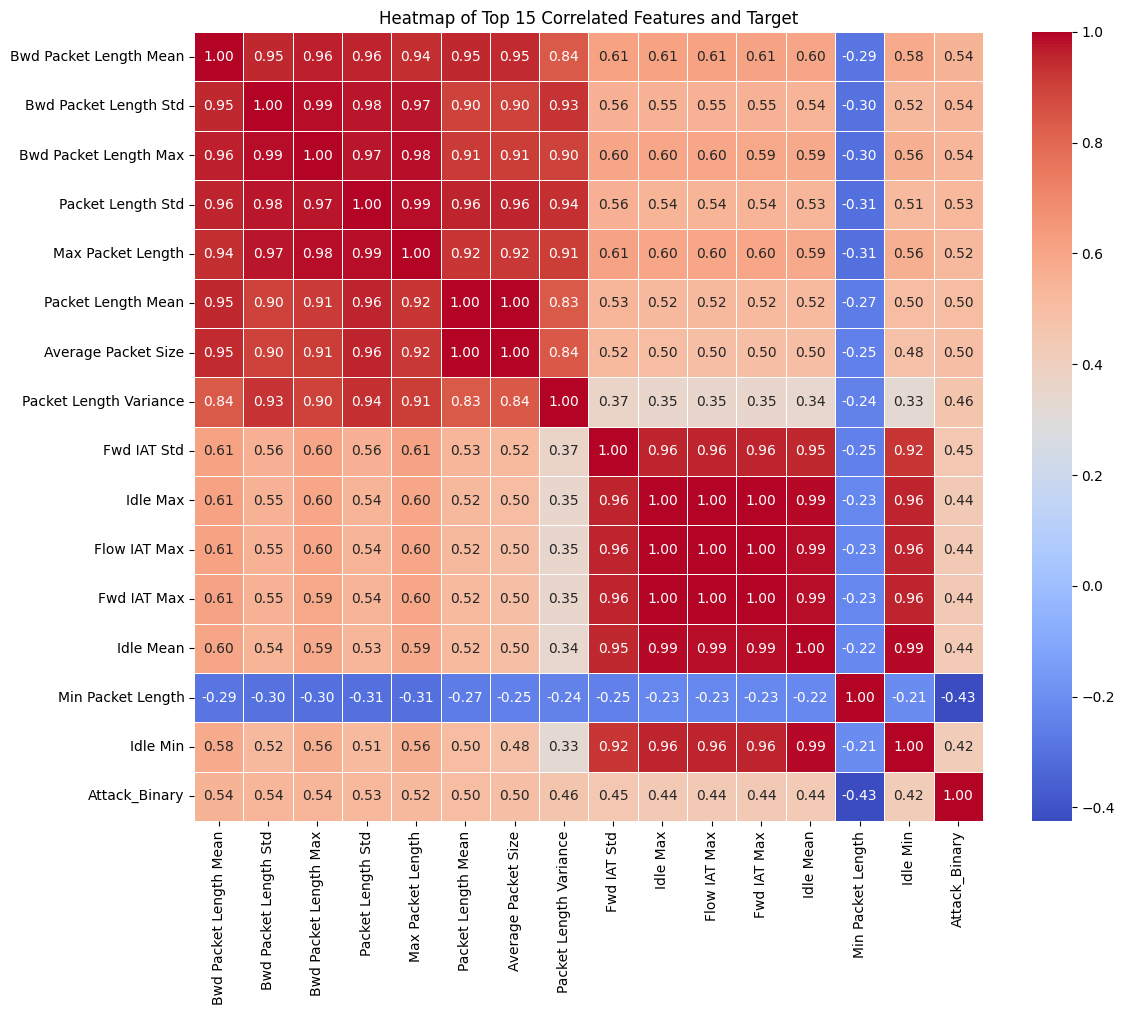

In [18]:
# Heatmap of the features with the strongest correlation to the target variable
# (selected for easier interpretation)

top_features = corr_target.abs().nlargest(15).index.tolist() + [TARGET]

plt.figure(figsize=(12, 10))
sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title('Heatmap of Top 15 Correlated Features and Target')
plt.tight_layout()
plt.show()

# 11. Negative values

In [19]:
# Check for columns containing negative values
neg_summary = {}

for col in feature_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        neg_summary[col] = {
            'count': neg_count,
            'min': df[col].min()
        }

if neg_summary:
    neg_df = pd.DataFrame(neg_summary).T
    print("Columns containing negative values:")
    print(neg_df.to_string())
else:
    print("No negative values found")

Columns containing negative values:
                            count           min
Flow Duration                14.0 -1.200000e+01
Flow Bytes/s                 10.0 -1.200000e+07
Flow Packets/s               14.0 -2.000000e+06
Flow IAT Mean                14.0 -1.200000e+01
Flow IAT Max                 14.0 -1.200000e+01
Flow IAT Min                706.0 -1.300000e+01
Fwd IAT Min                  17.0 -1.200000e+01
Fwd Header Length             7.0 -3.221223e+10
Bwd Header Length             5.0 -1.073741e+09
Init_Win_bytes_forward   185052.0 -1.000000e+00
Init_Win_bytes_backward  297259.0 -1.000000e+00
min_seg_size_forward          7.0 -5.368707e+08


In [20]:
# ──────────────────────────────────────────────────────────────────────────
# Columns that should not contain negative values in a network traffic context
# (durations, byte counts, header lengths, etc.)
# Replace negative values with NaN, then impute using the median
# ──────────────────────────────────────────────────────────────────────────

cols_no_neg = [
    'Flow Duration', 'Flow Bytes/s', 'Flow Packets/s',
    'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min',
    'Fwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
    'min_seg_size_forward'
]

# Ensure the columns exist before processing
cols_no_neg = [c for c in cols_no_neg if c in df.columns]

for col in cols_no_neg:
    before = (df[col] < 0).sum()
    df.loc[df[col] < 0, col] = np.nan
    print(f"{col}: Replaced {before} negative values with NaN")

df.fillna(df.median(numeric_only=True), inplace=True)

print("\n✅ Missing values were imputed using the median.")

Flow Duration: Replaced 14 negative values with NaN
Flow Bytes/s: Replaced 10 negative values with NaN
Flow Packets/s: Replaced 14 negative values with NaN
Flow IAT Mean: Replaced 14 negative values with NaN
Flow IAT Max: Replaced 14 negative values with NaN
Flow IAT Min: Replaced 706 negative values with NaN
Fwd IAT Min: Replaced 17 negative values with NaN
Fwd Header Length: Replaced 7 negative values with NaN
Bwd Header Length: Replaced 5 negative values with NaN
min_seg_size_forward: Replaced 7 negative values with NaN

✅ Missing values were imputed using the median.


In [21]:
for col in ['Init_Win_bytes_forward', 'Init_Win_bytes_backward']:

    print(f"\n{col}")

    temp = pd.crosstab(
        df[col] == -1,
        df['Attack_Binary'],
        normalize='index'
    ) * 100

    print(temp)

# The value -1 in Init_Win_bytes columns was retained because it showed a strong association
# with normal traffic and may provide useful information for intrusion detection.


Init_Win_bytes_forward
Attack_Binary                   0          1
Init_Win_bytes_forward                      
False                   36.114496  63.885504
True                    99.996217   0.003783

Init_Win_bytes_backward
Attack_Binary                    0          1
Init_Win_bytes_backward                      
False                    34.594249  65.405751
True                     78.716540  21.283460


# 12. Feature Engineering

In [22]:
df.columns.tolist()

['Destination Port',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Length of Fwd Packets',
 'Fwd Packet Length Max',
 'Fwd Packet Length Min',
 'Fwd Packet Length Mean',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Min',
 'Bwd Packet Length Mean',
 'Bwd Packet Length Std',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Total',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Total',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd Header Length',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Bwd Packets/s',
 'Min Packet Length',
 'Max Packet Length',
 'Packet Length Mean',
 'Packet Length Std',
 'Packet Length Variance',
 'FIN Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'Average Packet Size',
 'Subflow Fwd Bytes',
 'Init_Win_bytes_forward',
 'Init_Win_bytes_backward',
 'act_data_pkt_fwd',
 'min_seg_size_forward',
 'Active Mean',
 'Active M

In [23]:
# Feature 1: Forward Traffic Ratio
df['fwd_bwd_ratio'] = (
    df['Fwd Packets/s'] /
    (df['Fwd Packets/s'] + df['Bwd Packets/s'] + 1e-9)
)

# Measures the proportion of forward traffic relative to total traffic.
# Useful for identifying directional communication imbalances.

In [24]:
# Feature 2: Inter-Arrival Time Coefficient of Variation
df['iat_cv'] = (
    df['Flow IAT Std'] /
    (df['Flow IAT Mean'].abs() + 1e-9)
)

# Measures variability in packet arrival times relative to their average.
# Automated attacks often produce unusually regular or highly bursty traffic patterns.

In [25]:
# Feature 3: Traffic Intensity
df["Traffic_Intensity"] = (
    df["Flow Bytes/s"] *
    df["Flow Packets/s"]
)

# Combines data volume and packet transmission rate.
# Attacks such as DDoS often produce extremely high values for this feature.

In [26]:
# Feature 4: Active-to-Idle Ratio
df["Active_Idle_Ratio"] = (
    df["Active Mean"] /
    (df["Idle Mean"] + 1e-9)
)

# Measures how active a flow is relative to its idle periods.
# Helps distinguish continuous traffic from intermittent connections.

In [27]:
# Feature 5: Packet Length Variability
df["Packet_Variability"] = (
    df["Packet Length Std"] /
    (df["Packet Length Mean"] + 1e-9)
)

# Measures variation in packet sizes within a flow.
# Attack traffic may exhibit unusually high or low packet-size variability.

In [28]:
# Feature 6: Header Efficiency
df["Header_Efficiency"] = (
    df["Total Length of Fwd Packets"] /
    (df["Fwd Header Length"] + 1e-9)
)

# Measures payload data relative to header size.
# Useful for identifying unusual packet structures.

In [29]:
# Feature 7: Flow Activity Score
df["Flow_Activity"] = (
    df["Flow Packets/s"] *
    df["Active Mean"]
)

# Combines packet rate and activity duration.
# High values may indicate aggressive network behavior.

In [30]:
# Feature 8: Packet Size Range
df["Packet_Size_Range"] = (
    df["Max Packet Length"] -
    df["Min Packet Length"]
)

# Measures the spread between the largest and smallest packets.
# Can help distinguish different traffic behaviors.

In [31]:
df['Packet_Range_Ratio'] = (
    (df['Max Packet Length'] - df['Min Packet Length']) /
    (df['Packet Length Mean'] + 1e-9)
)

## 12.2 Visualizing the new features

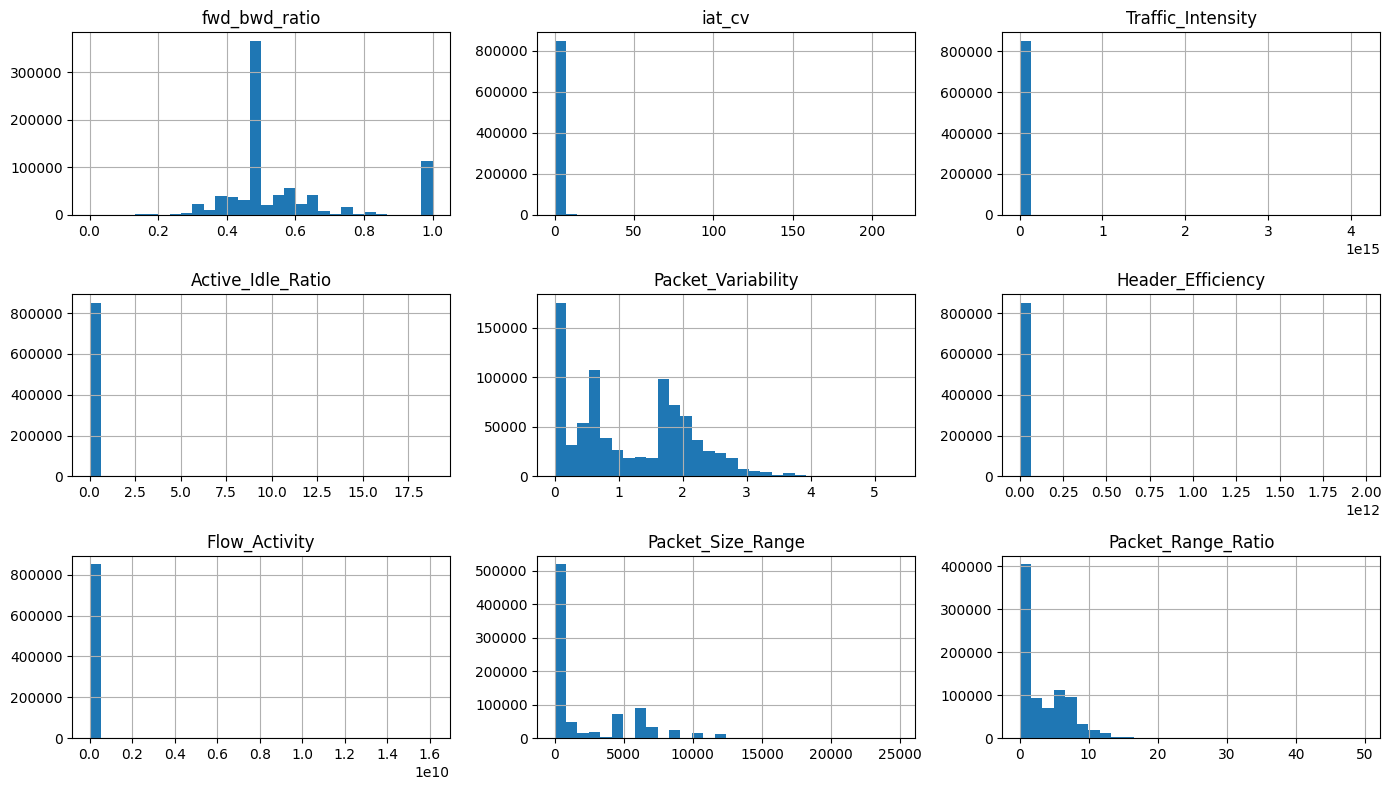

In [32]:
new_features = [
    'fwd_bwd_ratio',
    'iat_cv',
    'Traffic_Intensity',
    'Active_Idle_Ratio',
    'Packet_Variability',
    'Header_Efficiency',
    'Flow_Activity',
    'Packet_Size_Range',
    'Packet_Range_Ratio'
]

# Visualize the distribution of the engineered features.
# Helps identify skewness, unusual patterns, and extreme values.

df[new_features].hist(figsize=(14,8), bins=30)
plt.tight_layout()
plt.show()

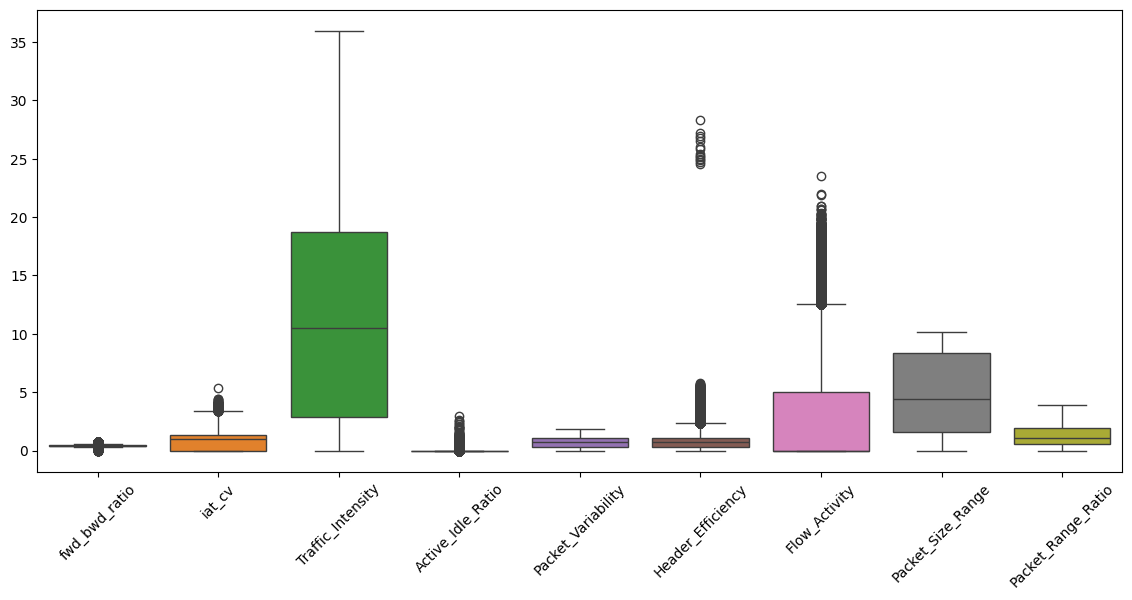

In [33]:
# Examine outliers and compare the spread of the engineered features.
df_log = df[new_features].copy()

for col in df_log.columns:
    df_log[col] = np.log1p(df_log[col])

plt.figure(figsize=(14,6))
sns.boxplot(data=df_log)
plt.xticks(rotation=45)
plt.show()

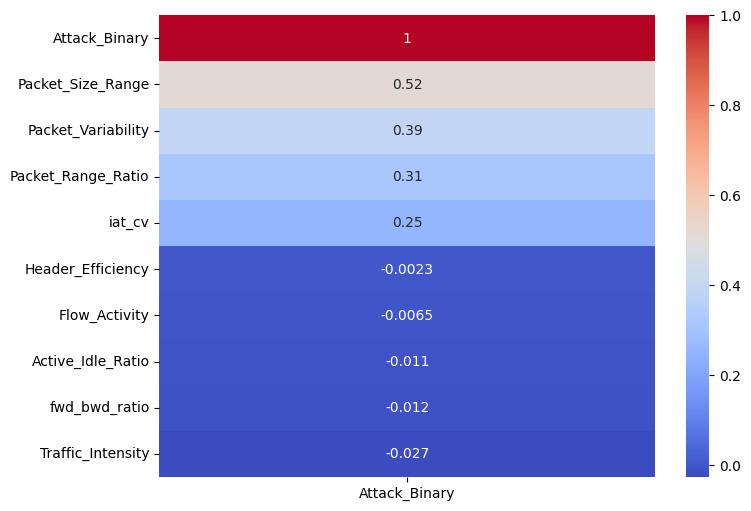

In [34]:
corr = df[new_features + ['Attack_Binary']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr[['Attack_Binary']]
    .sort_values('Attack_Binary', ascending=False),
    annot=True,
    cmap='coolwarm'
)
plt.show()

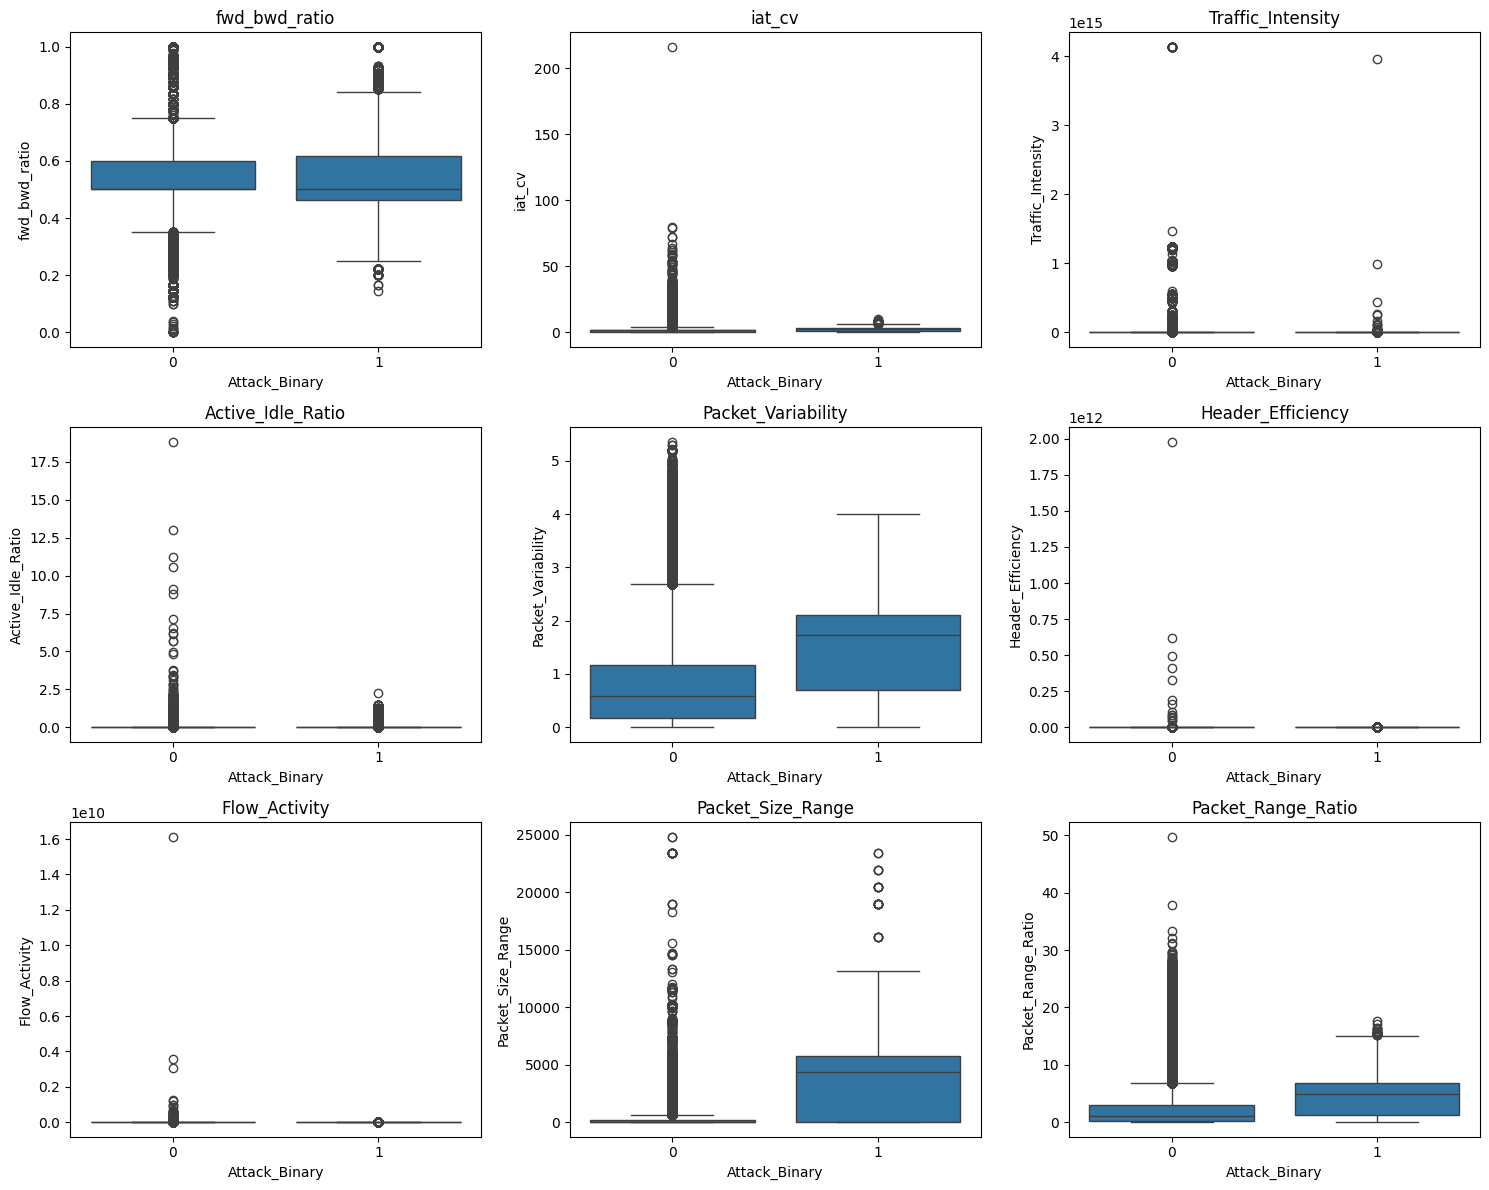

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(new_features):
    sns.boxplot(
        x='Attack_Binary',
        y=feature,
        data=df,
        ax=axes[i]
    )

    axes[i].set_title(feature)

for j in range(len(new_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 13. Insights

In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# Final Summary After All EDA Steps
# ═══════════════════════════════════════════════════════════════════════════

print("="*60)
print("📋 EDA Summary – CICIDS2017")
print("="*60)
print(f"  Final Dataset Shape     : {df.shape}")
print(f"  Remaining Missing Values: {df.isnull().sum().sum()}")
print(f"  Duplicate rows          : {df.duplicated().sum()}")
print(f"  Infinite Values         : {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"  Engineered Features     : {len(new_features)}")
print()

# Final target distribution
dist_final = df[TARGET].value_counts(normalize=True) * 100

print("Class Distribution:")
for cls, pct in dist_final.items():
    label = "Normal" if cls == 0 else "Attack"
    print(f"  {label} ({cls}): {pct:.1f}%")

print()
print("Key Findings:")
print("  1. The dataset is relatively balanced between normal and attack traffic.")
print("  2. Several columns contained unrealistic negative values, which were replaced using the median.")
print("  3. Few rows were duplicated, therfore they were dropped")
print("  3. Analysis of Init_Win_bytes_forward and Init_Win_bytes_backward revealed that the value -1 is strongly associated with normal traffic.\n Since these values appear to contain meaningful information rather than representing simple data errors, they were preserved in the dataset.")
print("  4. Newly engineered features (e.g., fwd_bwd_ratio, iat_cv, Packet_Size_Range) provide additional information for distinguishing attacks from normal traffic.")

📋 EDA Summary – CICIDS2017
  Final Dataset Shape     : (851380, 62)
  Remaining Missing Values: 0
  Duplicate rows          : 0
  Infinite Values         : 0
  Engineered Features     : 9

Class Distribution:
  Attack (1): 50.0%
  Normal (0): 50.0%

Key Findings:
  1. The dataset is relatively balanced between normal and attack traffic.
  2. Several columns contained unrealistic negative values, which were replaced using the median.
  3. Few rows were duplicated, therfore they were dropped
  3. Analysis of Init_Win_bytes_forward and Init_Win_bytes_backward revealed that the value -1 is strongly associated with normal traffic.
 Since these values appear to contain meaningful information rather than representing simple data errors, they were preserved in the dataset.
  4. Newly engineered features (e.g., fwd_bwd_ratio, iat_cv, Packet_Size_Range) provide additional information for distinguishing attacks from normal traffic.


#  nsights & Findings — CICIDS2017 EDA

> Exploratory analysis of network traffic to distinguish normal activity from cyberattacks

---

## 1. Dataset Overview

| Metric | Value |
|---|---|
| Original Shape | 851,388 rows × 53 columns |
| Shape After Cleaning | 851,380 rows × 62 columns (after feature engineering) |
| Remaining Missing Values | 0 |
| Duplicate Rows Removed | 8 rows |
| Infinite Values | 0 |
| Engineered Features Added | 9 new features |

---

## 2. Class Distribution (Target Variable)

| Class | Count | Percentage |
|---|---|---|
| Attack (1) | 425,694 | 50.0% |
| Normal (0) | 425,686 | 50.0% |

**Finding:** The dataset is perfectly balanced between attack and normal traffic, meaning **no resampling techniques** (e.g. SMOTE or oversampling) are needed during model training.

---

## 3. Strongest Features Correlated with Attacks

### Positively Correlated (higher value → more likely attack)

| Feature | Correlation |
|---|---|
| Bwd Packet Length Mean | **0.544** |
| Bwd Packet Length Std | 0.537 |
| Bwd Packet Length Max | 0.536 |
| Packet Length Std | 0.525 |
| Max Packet Length | 0.516 |
| Packet Length Mean | 0.501 |
| Average Packet Size | 0.496 |
| Packet Length Variance | 0.463 |
| Fwd IAT Std | 0.454 |
| Idle Max | 0.443 |

**Finding:** Attacks generate **larger and more variable backward (response) packets** compared to forward (request) packets. This reflects the nature of DoS/DDoS attacks where the server is forced to respond with large volumes of data.

### Negatively Correlated (lower value → more likely attack)

| Feature | Correlation |
|---|---|
| Min Packet Length | **-0.425** |
| Bwd Packet Length Min | -0.421 |
| Destination Port | -0.257 |
| Fwd Packet Length Min | -0.211 |
| Init_Win_bytes_backward | -0.154 |

**Finding:** Attacks tend to use **very small minimum packet sizes** — a signature of probe packets or flooding with miniaturized packets.

---

## 4. Key Discovery: Init_Win_bytes = -1

This is one of the most significant findings in the dataset.

| Column | Value | % Normal | % Attack |
|---|---|---|---|
| Init_Win_bytes_forward | = -1 | **99.99%** | 0.004% |
| Init_Win_bytes_forward | ≠ -1 | 36.1% | 63.9% |
| Init_Win_bytes_backward | = -1 | **78.7%** | 21.3% |
| Init_Win_bytes_backward | ≠ -1 | 34.6% | 65.4% |

**Finding:** A value of `-1` in `Init_Win_bytes_forward` is an almost certain indicator of **normal traffic** (99.99%). These are not data errors — they reflect connections that skip TCP Window negotiation (e.g. UDP or internal connections). These values were **deliberately retained** as a strong diagnostic signal rather than removed.

---

## 5. Data Quality & Cleaning Decisions

### Columns with Illogical Negative Values

| Column | Negative Count | Min Value |
|---|---|---|
| Flow IAT Min | 706 | -13 |
| Init_Win_bytes_forward | 185,052 | -1 |
| Init_Win_bytes_backward | 297,259 | -1 |
| Fwd Header Length | 7 | -32,212,230,000 |
| Flow Duration | 14 | -12 |

**Decisions made:**
- Columns like `Flow Duration`, `Flow IAT Min`, etc. → negative values replaced with the **median**, as negative durations/rates are physically impossible.
- `Init_Win_bytes` columns → `-1` values **retained**, as they carry strong analytical meaning (see Section 4).

---

## 6. Engineered Features & Their Purpose

| Feature | Formula | What It Measures |
|---|---|---|
| `fwd_bwd_ratio` | Fwd Packets/s ÷ (Fwd + Bwd + ε) | Traffic directionality — attacks tend to be one-directional |
| `iat_cv` | Flow IAT Std ÷ (Flow IAT Mean + ε) | Timing regularity — attacks are either robotic (very regular) or chaotic |
| `Traffic_Intensity` | Flow Bytes/s × Flow Packets/s | Overall pressure on the network |
| `Active_Idle_Ratio` | Active Mean ÷ (Idle Mean + ε) | Attacks run non-stop; normal traffic has natural idle periods |
| `Packet_Variability` | Packet Length Std ÷ (Packet Length Mean + ε) | Fluctuation in packet sizes |
| `Header_Efficiency` | Total Fwd Length ÷ (Fwd Header Length + ε) | Payload-to-header ratio — attacks carry more payload per header byte |
| `Flow_Activity` | Flow Packets/s × Active Mean | Overall connection activity level |
| `Packet_Size_Range` | Max − Min Packet Length | Diversity range of packet sizes |
| `Packet_Range_Ratio` | (Max − Min) ÷ (Mean + ε) | Relative size diversity across packets |

---

## 7. Key Takeaways

### The Attack Fingerprint

| Signal | Normal Traffic | Attack Traffic | Interpretation |
|---|---|---|---|
| Backward Packet Size | Moderate | **Very High** | Server overwhelmed with large responses |
| Min Packet Length | Moderate | **Very Low** | Small probe or flood packets |
| IAT Regularity | Natural variation | **Robotic or chaotic** | Automated tooling |
| Active / Idle | Intermittent | **Persistent, non-stop** | Relentless pressure |
| Init_Win = -1 | Very common | Almost never | Strong diagnostic marker |

### Why This Dataset Is Well-Suited for Classification

1. **Perfect 50/50 balance** — no training bias
2. **Strong, clear signals** — top correlation of 0.544 (excellent for security problems)
3. **Engineered features add value** — better class separation beyond raw features
4. **High data quality post-cleaning** — 0 missing values, 0 infinite values

---

*CICIDS2017 Binary Classification — EDA Analysis*